# Multiple Point Statistics with GSTools

Two-point geostatistics (covariance models, kriging, SRFs) describes spatial
structure through pairs of points and a variogram. This is powerful, but it
cannot reproduce *curvilinear* or *connected* features such as meandering
channels, fractures, or other patterns that depend on the joint configuration
of many points at once.

**Multiple Point Statistics (MPS)** addresses this by learning patterns
directly from a **training image (TI)** — an example image deemed
representative of the spatial structure to simulate. Instead of fitting a
variogram, MPS borrows whole patterns from the TI.

GSTools provides the **Direct Sampling (DS)** algorithm
([Mariethoz et al., 2010](https://doi.org/10.1029/2008WR007621)), together
with the **Direct Sampling Best Candidate (DSBC)** parametrization
([Juda et al., 2022](https://doi.org/10.1016/j.acags.2022.100091)), through
two classes:

* `TrainingImage` — the MPS model: the training image plus the distance
  used to compare patterns (the analogue of a `CovModel`).
* `DirectSampling` — the generator that produces realizations on a
  structured grid (the analogue of `SRF`).

The core idea: to fill each grid cell, DS looks at the values already present
around it (its *data event*), scans the training image for a location whose
surroundings look similar enough, and copies that cell's value over.
"Similar enough" is decided by a **distance** between the two surroundings,
controlled by three parameters — the number of neighbours `n`, the scan
fraction `f`, and the acceptance threshold `t` (with `t = 0` giving the
recommended DSBC mode).

This notebook gathers the `examples/13_mps/` gallery into one place and
builds up from a minimal unconditional simulation to conditioning,
continuous variables, and a real, published training image:

1. [A first Direct Sampling simulation](#1.-A-first-Direct-Sampling-simulation)
2. [Conditioning to hard data](#2.-Conditioning-to-hard-data)
3. [Continuous variables and distance metrics](#3.-Continuous-variables-and-distance-metrics)
4. [A real training image: the Strebelle channels](#4.-A-real-training-image:-the-Strebelle-channels)

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.ioff()
# turn off warnings for a cleaner notebook
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
from matplotlib.colors import ListedColormap

import gstools as gs

## 1. A first Direct Sampling simulation

This is the minimal Multiple Point Statistics example: build a training
image, wrap it in a `TrainingImage`, and generate one unconditional
realization with `DirectSampling`.

We use a small, synthetic *channelized* training image generated with
NumPy, so the example is fast and needs no downloads.

Create a synthetic binary training image with curvilinear "channels".
The two facies (0 and 1) form connected, meandering bands — exactly the kind
of structure two-point statistics struggles to reproduce.

In [3]:
gx, gy = np.meshgrid(np.arange(60), np.arange(60), indexing="ij")
ti_data = ((np.sin(gx / 5.0) + np.sin((gx + gy) / 8.0)) > 0).astype(float)

Wrap the array in a `TrainingImage`. For a categorical variable (facies
codes) the distance is the fraction of mismatching neighbours, so the
`distance` argument is ignored here.

In [4]:
ti = gs.TrainingImage(ti_data, categorical=True)
print(ti)

TrainingImage(shape=(60, 60), categorical=True, distance='l1')


Create the `DirectSampling` generator and simulate on a 40x40 grid.

* `n_neighbors` — how many already-known cells define each data event.
* `scan_fraction` — fraction of the training image scanned per cell
  (smaller is faster, slightly noisier).
* `threshold=0.0` — the recommended DSBC mode: always take the best match.

In [5]:
ds = gs.DirectSampling(
    gs.MPSModel(ti, n_neighbors=12, scan_fraction=0.3, threshold=0.0)
)
field_simple = ds([np.arange(40, dtype=float)] * 2, seed=20250616)

Plot the training image next to the realization. The realization is not a
copy of the TI, but it reproduces the same channel patterns.

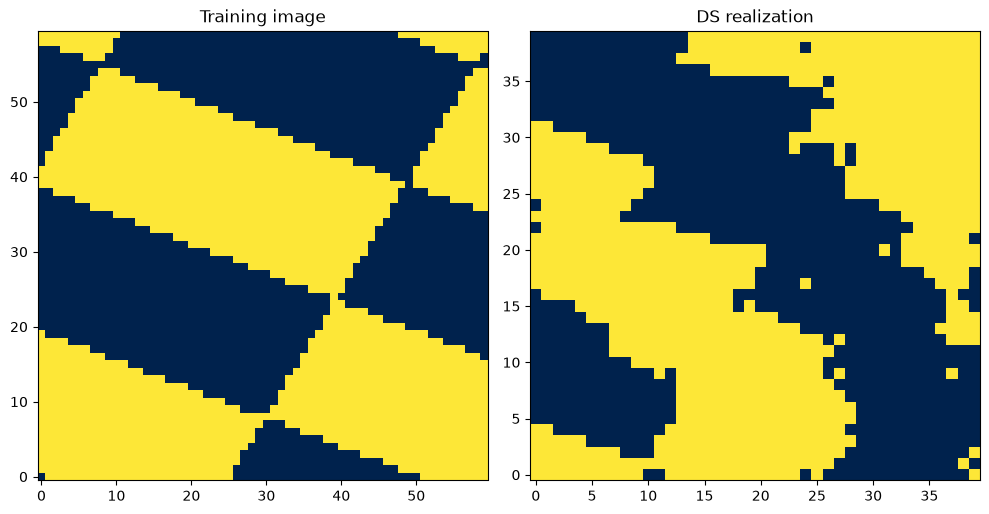

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(ti_data, cmap="cividis", origin="lower")
ax0.set_title("Training image")
ax1.imshow(field_simple, cmap="cividis", origin="lower")
ax1.set_title("DS realization")
fig.tight_layout()
plt.show()

## 2. Conditioning to hard data

Real simulations must honour measured data (boreholes, samples). Direct
Sampling supports this through `DirectSampling.set_condition`: conditioning
values are pinned into the grid before simulation and preserved exactly,
while the rest of the field is filled in around them.

We reuse the synthetic channel training image from the first example.

Draw 40 random "hard data" points and read their facies from the TI. In a
real study these would be field measurements; here we sample the TI so the
conditioning data are consistent with the patterns.

In [7]:
rng = np.random.default_rng(0)
cond_x = rng.integers(0, 40, 40).astype(float)
cond_y = rng.integers(0, 40, 40).astype(float)
cond_val = ti_data[cond_x.astype(int), cond_y.astype(int)]

Set the conditioning data and simulate. `set_condition` snaps each point to
its nearest grid node, so the values are honoured exactly at those cells.

In [8]:
ds_cond = gs.DirectSampling(
    gs.MPSModel(ti, n_neighbors=12, scan_fraction=0.3, threshold=0.0)
)
ds_cond.set_condition([cond_x, cond_y], cond_val)
field_cond = ds_cond([np.arange(40, dtype=float)] * 2, seed=7)

honored = int(
    (field_cond[cond_x.astype(int), cond_y.astype(int)] == cond_val).sum()
)
print(f"conditioning honoured: {honored}/{cond_val.size}")

conditioning honoured: 40/40


Plot the realization with the conditioning points overlaid. Every marker sits
on a cell whose simulated facies matches the datum.

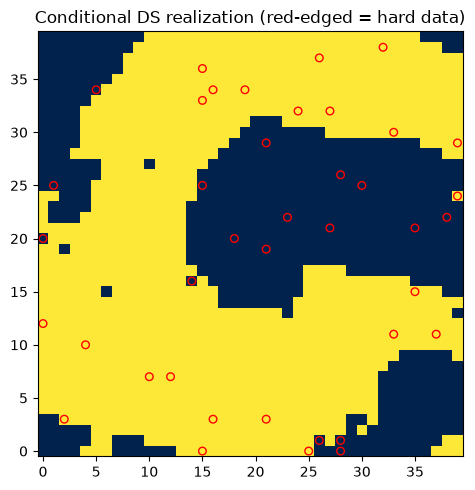

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(field_cond, cmap="cividis", origin="lower")
ax.scatter(
    cond_y, cond_x, c=cond_val, cmap="cividis", edgecolors="red", s=30
)
ax.set_title("Conditional DS realization (red-edged = hard data)")
fig.tight_layout()
plt.show()

## 3. Continuous variables and distance metrics

Direct Sampling is not limited to categorical facies: with
`categorical=False` it simulates continuous variables (permeability,
porosity, elevation, ...). The `distance` argument then selects how two
patterns are compared:

* `"l1"` / `"l2"` — Manhattan / Euclidean distance on the raw values
  (Mariethoz et al., 2010, Eq. 6 / Eq. 4).
* `"variation"` — compares only the *relative* variations within a pattern
  (Eq. 9), tolerating a locally varying mean. Useful for non-stationary data.

Here we use a smooth continuous training image and a small acceptance
`threshold` (standard DS mode) to allow approximate matches.

A smooth, continuous synthetic training image.

In [10]:
gx, gy = np.meshgrid(np.arange(60), np.arange(60), indexing="ij")
ti_cont_data = np.sin(gx / 6.0) * np.cos(gy / 8.0)

Build a continuous training image with the Euclidean (`"l2"`) distance.

In [11]:
ti_cont = gs.TrainingImage(ti_cont_data, categorical=False, distance="l2")
print(ti_cont)

TrainingImage(shape=(60, 60), categorical=False, distance='l2')


Simulate. `threshold=0.03` accepts the first pattern within that distance
(standard DS), which is faster than the exhaustive best-candidate search for
continuous variables.

In [12]:
ds_cont = gs.DirectSampling(
    gs.MPSModel(ti_cont, n_neighbors=12, scan_fraction=0.3, threshold=0.03)
)
field_cont = ds_cont([np.arange(32, dtype=float)] * 2, seed=3)

Plot. The realization reproduces the smooth wavy structure of the TI without
copying it. A shared colour scale makes the comparison fair.

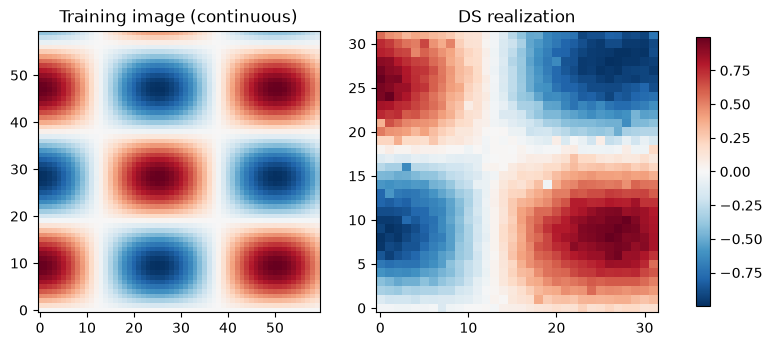

In [13]:
vmin, vmax = ti_cont_data.min(), ti_cont_data.max()
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
im = ax0.imshow(
    ti_cont_data, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax
)
ax0.set_title("Training image (continuous)")
ax1.imshow(field_cont, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
ax1.set_title("DS realization")
fig.colorbar(im, ax=(ax0, ax1), shrink=0.7)
plt.show()

## 4. A real training image: the Strebelle channels

The previous examples used tiny synthetic training images. Here we use the
classic **Strebelle (2002) channelized fluvial training image**, the de-facto
benchmark for MPS, and condition the simulation on random hard data.

> **Data source / license.** The training image is downloaded from the
> [GeoDataSets](https://github.com/GeostatsGuy/GeoDataSets) repository by
> Michael Pyrcz (GeostatsGuy), which is distributed under the **MIT license**
> (redistribution permitted with attribution). The underlying channel TI is
> due to Strebelle, S. (2002), *Conditional simulation of complex geological
> structures using multiple-point statistics*, Mathematical Geology, 34(1),
> 1-21. If the download is unavailable, the example falls back to a synthetic
> training image so it still runs offline.

Load the Strebelle training image, with a synthetic fallback for offline use.

In [14]:
import os
import urllib.request

TI_URL = (
    "https://raw.githubusercontent.com/GeostatsGuy/"
    "GeoDataSets/master/MPS_Training_image_and_Realizations_500.npz"
)
CACHE = "mps_strebelle.npz"
try:
    if not os.path.exists(CACHE):
        urllib.request.urlretrieve(TI_URL, CACHE)
    ti_strebelle_arr = np.load(CACHE)["array1"].astype(float)
    source = "Strebelle (2002) via GeoDataSets (MIT)"
except Exception as err:  # network fallback
    print(f"download failed ({err}); using a synthetic channel TI instead")
    gx, gy = np.meshgrid(np.arange(150), np.arange(150), indexing="ij")
    ti_strebelle_arr = (
        (np.sin(gx / 6.0) + np.sin((gx + gy) / 10.0)) > 0
    ).astype(float)
    source = "synthetic fallback"

ti_strebelle = gs.TrainingImage(ti_strebelle_arr, categorical=True)
print(f"TI {ti_strebelle.shape} ({source}), sand fraction = {ti_strebelle_arr.mean():.3f}")

TI (256, 256) (Strebelle (2002) via GeoDataSets (MIT)), sand fraction = 0.291


Take 80 random conditioning points from the training image patterns.

In [15]:
sg_size = 80
rng = np.random.default_rng(0)
cond_x = rng.integers(0, sg_size, 80).astype(float)
cond_y = rng.integers(0, sg_size, 80).astype(float)
cond_val = ti_strebelle_arr[cond_x.astype(int), cond_y.astype(int)]

Simulate with DSBC-style parameters (best-candidate + partial scan).

In [16]:
ds_strebelle = gs.DirectSampling(
    gs.MPSModel(ti_strebelle, n_neighbors=30, scan_fraction=0.2, threshold=0.0)
)
ds_strebelle.set_condition([cond_x, cond_y], cond_val)
field_strebelle = ds_strebelle([np.arange(sg_size, dtype=float)] * 2, seed=42)

honored = int(
    (
        field_strebelle[cond_x.astype(int), cond_y.astype(int)] == cond_val
    ).sum()
)
print(f"conditioning honoured: {honored}/{cond_val.size}")

conditioning honoured: 80/80


Plot the training image crop next to the conditional realization.

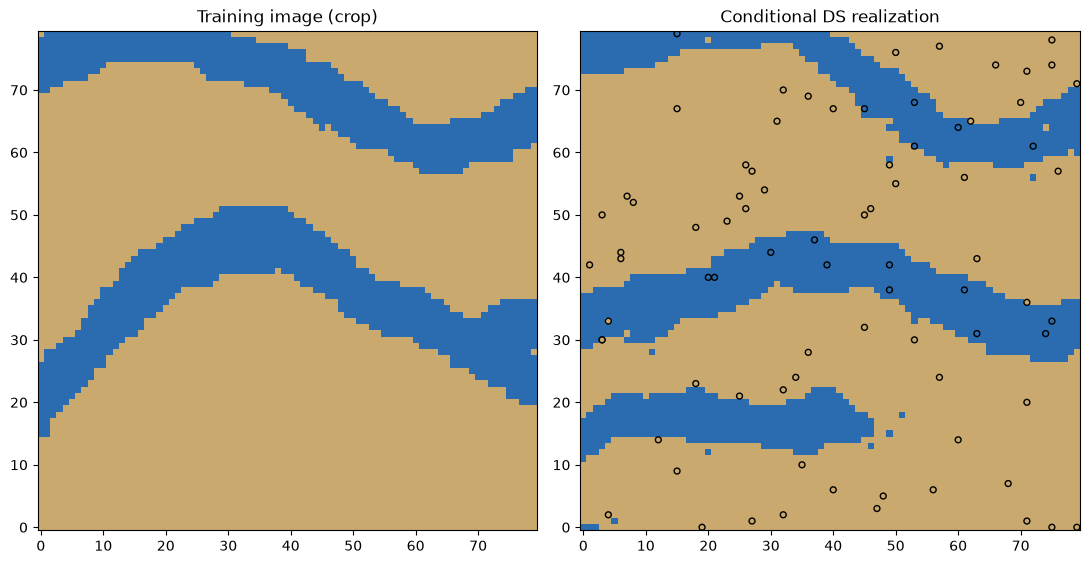

In [17]:
cmap = ListedColormap(["#c9a96e", "#2b6cb0"])  # shale / sand
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5.5))
ax0.imshow(ti_strebelle_arr[:sg_size, :sg_size], cmap=cmap, origin="lower")
ax0.set_title("Training image (crop)")
ax1.imshow(field_strebelle, cmap=cmap, origin="lower")
ax1.scatter(cond_y, cond_x, c=cond_val, cmap=cmap, edgecolors="k", s=18)
ax1.set_title("Conditional DS realization")
fig.tight_layout()
plt.show()

## Next steps

* The standalone, sphinx-gallery versions of these four examples live in
  this same folder (`00_simple_unconditional.py`, `01_conditional.py`,
  `02_continuous.py`, `03_channel_strebelle.py`) and are built into the
  online documentation gallery.
* For a deeper dive into the algorithm internals (the distance layer, the
  parallel DAG engine, and an equation map to Mariethoz (2010) / Juda
  (2022)), see `src/gstools/mps/CODE_GUIDE.md`.